In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
from model import VSF_model, get_pk_interp, variance

/home/alex/Documents/axions/axionHMcode_fast/solvers/root_finders.py:8: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def brent(f, x1, x3):
/home/alex/Documents/axions/axionHMcode_fast/solvers/root_finders.py:34: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def newton(f, x0, y=0, args=None):


Time to generate Pk from interpolation:  0.0013338720000000137


Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG IEEE_DENORMAL


In [3]:
plt.rcParams.update({"text.usetex":True})

In [4]:
col = ['#332288', '#117733',]

In [5]:
h = 0.6737
R_array = np.geomspace(5, 85, 1_000)
Nbins = 10
bin_edges = np.geomspace(25, 40, Nbins+1)
bin_cens = (bin_edges[:-1]+bin_edges[1:])/2

void_radii_ax = np.loadtxt('data/test_new_radii_m25.dat')
N_data_ax = np.histogram(void_radii_ax, bins=bin_edges)[0]
N_data_ax_plus = np.histogram(void_radii_ax, bins=bin_edges)[0] + np.sqrt(np.histogram(void_radii_ax, bins=bin_edges)[0])
N_data_ax_minus = np.histogram(void_radii_ax, bins=bin_edges)[0] - np.sqrt(np.histogram(void_radii_ax, bins=bin_edges)[0])

void_radii_cdm = np.loadtxt('data/test_new_radii_lcdm.dat')
N_data_cdm = np.histogram(void_radii_cdm, bins=bin_edges)[0]
N_data_cdm_plus = np.histogram(void_radii_cdm, bins=bin_edges)[0] + np.sqrt(np.histogram(void_radii_cdm, bins=bin_edges)[0])
N_data_cdm_minus = np.histogram(void_radii_cdm, bins=bin_edges)[0] - np.sqrt(np.histogram(void_radii_cdm, bins=bin_edges)[0])

boxsize = 2048*h

In [6]:
s = [(R_array > bin_edges[i]) & (R_array < bin_edges[i+1]) for i in range(Nbins)]
k, P = get_pk_interp([3.043, 0.31, 0.0001])
R, var = variance(k, P)
model, sig8 = VSF_model(1.32, R, var)

In [7]:
s = [(R_array > bin_edges[i]) & (R_array < bin_edges[i+1]) for i in range(Nbins)]
k, P = get_pk_interp([3.043, 0.31, 0.1])
R, var = variance(k, P)
model_ax, sig8_ax = VSF_model(1.49, R, var)

In [8]:
sig8_ax

array([0.70172197])

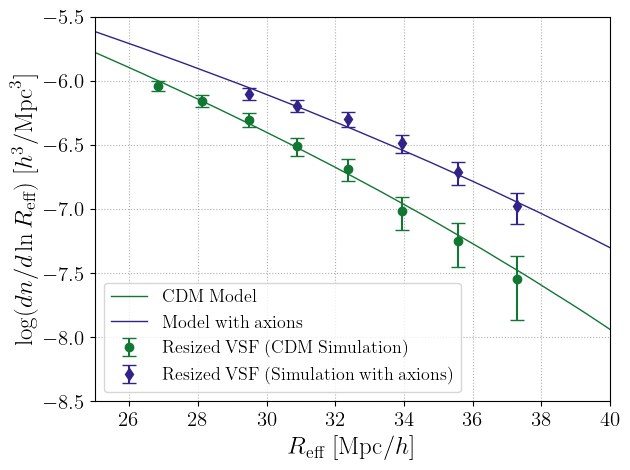

In [133]:
plt.plot(R_array, np.log10(model), label='$\mathrm{CDM\;Model}$', c=col[1], lw=1)
plt.plot(R_array, np.log10(model_ax), label='$\mathrm{Model \;with \;axions}$', c=col[0], lw=1)


log_dn_dlnR_cdm = np.log10(np.gradient(np.cumsum(N_data_cdm)/boxsize**3, np.log(bin_cens)))[1:-1]
err_plus_cdm = np.log10(np.gradient(np.cumsum(N_data_cdm_plus)/boxsize**3, np.log(bin_cens)))[1:-1] - log_dn_dlnR_cdm
err_minus_cdm = -np.log10(np.gradient(np.cumsum(N_data_cdm_minus)/boxsize**3, np.log(bin_cens)))[1:-1] + log_dn_dlnR_cdm
err_cdm = np.array(list(zip(err_minus_cdm, err_plus_cdm))).T
#plt.plot(bin_cens[1:-1], np.log10(np.gradient(np.cumsum(N_data_cdm)/boxsize**3, np.log(bin_cens)))[1:-1], 'o-')
plt.errorbar(bin_cens[1:-1], log_dn_dlnR_cdm, yerr=err_cdm, fmt='o', capsize=5, c=col[1],
             label='$\mathrm{Resized\;VSF\;(CDM\;Simulation)}$')

log_dn_dlnR_ax = np.log10(np.gradient(np.cumsum(N_data_ax)/boxsize**3, np.log(bin_cens)))[3:-1]
err_plus_ax = np.log10(np.gradient(np.cumsum(N_data_ax_plus)/boxsize**3, np.log(bin_cens)))[3:-1] - log_dn_dlnR_ax
err_minus_ax = -np.log10(np.gradient(np.cumsum(N_data_ax_minus)/boxsize**3, np.log(bin_cens)))[3:-1] + log_dn_dlnR_ax
err_ax = np.array(list(zip(err_minus_ax, err_plus_ax))).T
plt.errorbar(bin_cens[3:-1], log_dn_dlnR_ax, yerr=err_ax, fmt='d', c=col[0],
             capsize=5, label='$\mathrm{Resized\;VSF\;(Simulation\;with\;axions)}$')

#plt.plot(bin_cens[3:-1], , '--')
#plt.plot(bin_cens[3:-1], np.log10(np.gradient(np.cumsum(N_data_ax_minus)/boxsize**3, np.log(bin_cens)))[3:-1], '--')

plt.xlim(25, 40)
plt.ylim(-8.5, -5.5)
plt.xlabel('$R_\mathrm{eff}\;[\mathrm{Mpc}/h]$',fontsize=18)
plt.ylabel('$\log( dn/d\ln R_\mathrm{eff})\;[h^3/\mathrm{Mpc}^3]$',fontsize=18)
plt.legend(fontsize=13)
plt.grid(ls=':', which='both')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.savefig('figures/vsf-model-with-data.png', dpi=800)
plt.show()

In [134]:
%matplotlib inline

/tmp/ipykernel_179739/3624605572.py:41: RuntimeWarning: invalid value encountered in log10
  plt.plot(R_array, np.log10(model), c=plt.cm.RdBu_r(np.linspace(0.0001, 1, 150))[i], lw=2.5)


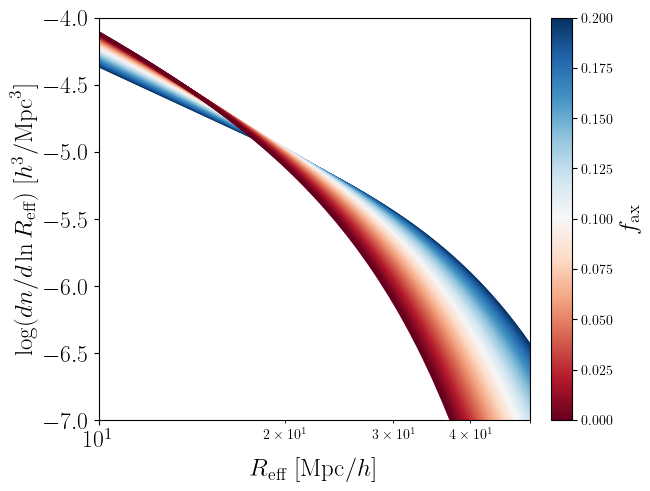

In [135]:
from colossus.lss import bias
from colossus.lss import peaks, mass_function
from colossus.cosmology import cosmology
from scipy.interpolate import CubicSpline

M = 5E13
cosmology.setCosmology('planck18')
Rhalo = peaks.lagrangianR(M)
z = 0.0
#nu = peaks.peakHeight(M, z)

#b = bias.haloBias(M, model = 'tinker10', z = z, mdef = 'vir')

xs= []
ys=[]


fig, ax = plt.subplots(layout='constrained')

cb = fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 0.2), cmap='RdBu'),
             ax=ax, orientation='vertical',)

cb.set_label(label='$f_\mathrm{ax}$',size=18,)
for i, fax in enumerate(np.linspace(0.0001, 0.2, 150)[::-1]):
    s = [(R_array > bin_edges[i]) & (R_array < bin_edges[i+1]) for i in range(Nbins)]
    k, P = get_pk_interp([3.043, 0.31, fax])
    R, var = variance(k, P)
    #sigma = CubicSpline(R, var)(R)
    nu = 1.686 / np.sqrt(var[R>peaks.lagrangianR(1e13*0.68)])
    b_of_M = bias.haloBiasFromNu(nu, model = 'sheth01')
    hmf = mass_function.massFunction(nu, 0.0, model = 'sheth99', q_in= 'nu', q_out = 'dndlnM')
    M = peaks.lagrangianM(R[R>peaks.lagrangianR(1e13*0.68)])
    b = np.trapz(b_of_M*hmf, x=np.log(M)) / np.trapz(hmf, x=np.log(M))
    #print(b, fax)
    #b = 1+ (nu**2-1) / 1.686
    #b = np.min(b[b>0])
    
    model, sig8 = VSF_model(b, R, var)
    #xs.append(R_array)
    #ys.append(model)
    plt.plot(R_array, np.log10(model), c=plt.cm.RdBu_r(np.linspace(0.0001, 1, 150))[i], lw=2.5)
#fig, ax = plt.subplots()
#lc = multiline(xs, ys, 50, cmap='bwr', lw=2)

plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.xlim(10, 50)
plt.ylim(-7, -4.)
plt.xscale('log')
plt.xlabel('$R_\mathrm{eff}\;[\mathrm{Mpc}/h]$',fontsize=18)
plt.ylabel('$\log( dn/d\ln R_\mathrm{eff})\;[h^3/\mathrm{Mpc}^3]$',fontsize=18)

#plt.tight_layout()

plt.savefig('figures/vsf-model-changing-ax-frac.png', dpi=600)


(200,)

In [177]:
b = 1+ (nu**2-1) / 1.686
np.mean(b[b<5])

4.045882308714014